In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Definir caminhos
path_data  = "../data/"

# Carregar o arquivo
df = pd.read_csv(path_data + '2_envio_case_base_Total_2026.csv', sep=';', encoding='latin-1')

# Formatação da coluna 'ano_mes' para datetime
df['ano_mes'] = pd.to_datetime(df['ano_mes'], format='%Y%m')

df.head()

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado
0,534521536,2023-01-01,3_5,Chevrolet,"(25000, 70000]",43,solteiro,0,18422,SE,liberais,20,12,2775,0.0,0.0,8,1
1,894445785,2023-01-01,10,Chevrolet,"(25000, 70000]",39,solteiro,0,11175,N,empresarios,20,48,734,0.0,0.0,5,1
2,510004819,2023-01-01,1_2,Fiat,"(25000, 70000]",37,solteiro,>2,26031,NE,consignados,30,36,1510,1.0,0.0,7,1
3,230978528,2023-01-01,10,VW,"(25000, 70000]",61,casado,0,3009,SE,empresarios,20,36,1588,1.0,0.0,4,1
4,489909079,2023-01-01,3_5,Fiat,"(25000, 70000]",48,casado,2,10253,CO,assalariados,30,12,2712,0.0,0.0,8,1


In [55]:
# Separar os dados em contratados e não contratados
df_descontinuado = df[(df['contratado'] == 0)]
df_contratado    = df[(df['contratado'] == 1)]

# Separar os dados em contratados inadimplentes e adimplentes
df_inadimplente = df[(df['contratado'] == 1) & 
                     (df['target'] == 1)]                  
df_adimplente   = df[(df['contratado'] == 1) & 
                     (df['target'] == 0)]
 
# Imprimir o total de contratados, descontinuados, inadimplentes e adimplentes
print("Total de descontinuados : ", f"{len(df_descontinuado):,}")
print("Total de contratados    : ", f"{len(df_contratado):,}")
print("Total de adimplentes    : ", f"{len(df_adimplente):,}")
print("Total de inadimplentes  : ", f"{len(df_inadimplente):,}")

Total de descontinuados :  192,550
Total de contratados    :  655,451
Total de adimplentes    :  587,596
Total de inadimplentes  :  67,855


In [47]:
df_contratado.describe().T

,count,mean,min,25%,50%,75%,max,std
id,655451.0,550344829.796738,100000316.0,325319883.5,550605692.0,775445026.5,999999446.0,259875560.850485
ano_mes,655451,2023-12-06 12:45:31.459102,2022-03-01 00:00:00,2023-01-01 00:00:00,2023-12-01 00:00:00,2024-11-01 00:00:00,2025-12-01 00:00:00,NaN
idade,655451.0,40.315195,18.0,34.0,40.0,47.0,87.0,9.87442
renda,655451.0,13709.077272,3000.0,4397.0,12327.0,22792.0,27576.0,9016.625373
entrada,655451.0,24.292022,0.0,10.0,20.0,40.0,50.0,15.661309
prazo,655451.0,39.351372,12.0,36.0,36.0,48.0,60.0,10.990441
pmt,655451.0,1198.184763,216.0,752.0,1089.0,1486.0,9197.0,654.266414
target,655451.0,0.103524,0.0,0.0,0.0,0.0,1.0,0.304642
FPD,655451.0,0.03315,0.0,0.0,0.0,0.0,1.0,0.179027
score,655451.0,6.751287,1.0,6.0,7.0,8.0,10.0,1.65564


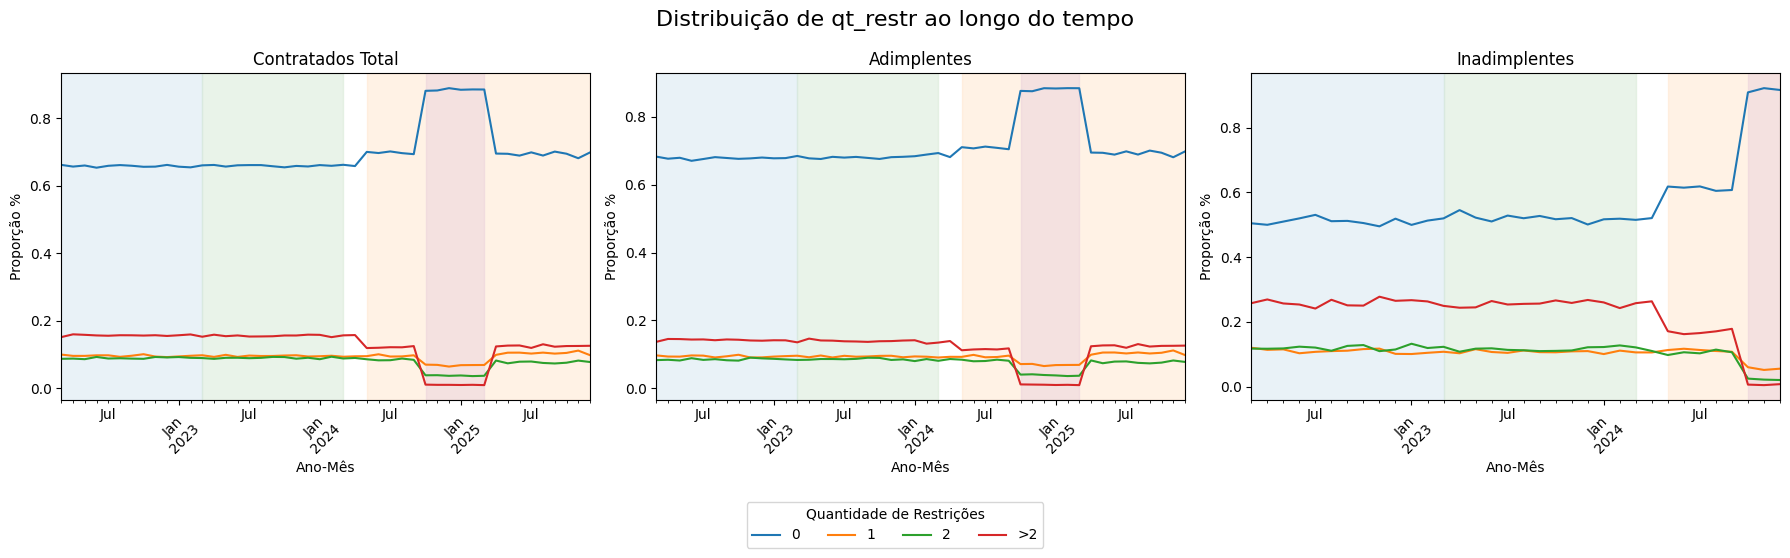

In [70]:
col = 'qt_restr'

# Criar as tabelas para cada grupo
tabela_contratado   = pd.crosstab(df_contratado['ano_mes'], df_contratado[col], normalize='index')
tabela_inadimplente = pd.crosstab(df_inadimplente['ano_mes'], df_inadimplente[col], normalize='index')
tabela_adimplente   = pd.crosstab(df_adimplente['ano_mes'], df_adimplente[col], normalize='index')

# Criar figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lista com as tabelas e títulos
tabelas = [
    (tabela_contratado, 'Contratados Total'),
    (tabela_adimplente, 'Adimplentes'),
    (tabela_inadimplente, 'Inadimplentes')
]

# Título geral da figura
fig.suptitle(f'Distribuição de {col} ao longo do tempo', 
             fontsize=16)

# Plotar cada gráfico
for ax, (tabela, titulo) in zip(axes, tabelas):
    tabela.plot(ax=ax, figsize=(18,5), legend=False)  # Remover legenda individual
    
    # Pintar fundo dos diferentes períodos 
    ax.axvspan('2022-03-01', '2023-03-01', color='#D4E6F1', alpha=0.5)        # modelagem
    ax.axvspan('2023-03-01', '2024-03-01', color='#D5E8D4', alpha=0.5)        # janela de observação
    ax.axvspan('2024-05-01', tabela.index.max(), color='#FFE6CC', alpha=0.5)  # produção
    ax.axvspan('2024-10-01', '2025-03-01', color='#EAD1DC', alpha=0.5)        # estranho
    
    ax.set_title(titulo)
    ax.set_xlabel('Ano-Mês')
    ax.set_ylabel('Proporção %')
    
    # Rotacionar labels do eixo x para melhor legibilidade
    ax.tick_params(axis='x', rotation=45)

# Criar uma única legenda para todos os gráficos
# Pegar as cores e labels do primeiro gráfico
lines = axes[0].get_lines()
labels = [line.get_label() for line in lines]

# Posicionar a legenda fora dos gráficos
fig.legend(lines, labels, 
           loc='center', 
           bbox_to_anchor=(0.5, -0.05),       # Posição abaixo dos gráficos
           ncol=len(labels),                  # Uma coluna para cada categoria
           title='Quantidade de Restrições')  # Título da legenda

# Ajustar espaçamento para não cortar a legenda
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Aumentar espaço na parte inferior

plt.show()

In [ ]:
col = 'qt_restr'

# Criar as tabelas para cada grupo
tabela_contratado   = pd.crosstab(df_contratado['ano_mes'], df_contratado[col], normalize='index')
tabela_inadimplente = pd.crosstab(df_inadimplente['ano_mes'], df_inadimplente[col], normalize='index')
tabela_adimplente   = pd.crosstab(df_adimplente['ano_mes'], df_adimplente[col], normalize='index')

# Criar figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lista com as tabelas e títulos
tabelas = [
    (tabela_contratado, 'Contratados Total'),
    (tabela_adimplente, 'Adimplentes'),
    (tabela_inadimplente, 'Inadimplentes')
]

# Título geral da figura
fig.suptitle(f'Distribuição de {col} ao longo do tempo', 
             fontsize=16)

# Plotar cada gráfico
for ax, (tabela, titulo) in zip(axes, tabelas):
    tabela.plot(ax=ax, figsize=(18,5), legend=False)  # Remover legenda individual
    
    # Pintar fundo dos diferentes períodos 
    ax.axvspan('2022-03-01', '2023-03-01', color='#D4E6F1', alpha=0.5)        # modelagem
    ax.axvspan('2023-03-01', '2024-03-01', color='#D5E8D4', alpha=0.5)        # janela de observação
    ax.axvspan('2024-05-01', tabela.index.max(), color='#FFE6CC', alpha=0.5)  # produção
    ax.axvspan('2024-10-01', '2025-03-01', color='#EAD1DC', alpha=0.5)        # estranho
    
    ax.set_title(titulo)
    ax.set_xlabel('Ano-Mês')
    ax.set_ylabel('Proporção %')
    
    # Rotacionar labels do eixo x para melhor legibilidade
    ax.tick_params(axis='x', rotation=45)

# Criar uma única legenda para todos os gráficos
# Pegar as cores e labels do primeiro gráfico
lines = axes[0].get_lines()
labels = [line.get_label() for line in lines]

# Posicionar a legenda fora dos gráficos
fig.legend(lines, labels, 
           loc='center', 
           bbox_to_anchor=(0.5, -0.05),       # Posição abaixo dos gráficos
           ncol=len(labels),                  # Uma coluna para cada categoria
           title='Quantidade de Restrições')  # Título da legenda

# Ajustar espaçamento para não cortar a legenda
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Aumentar espaço na parte inferior

plt.show()

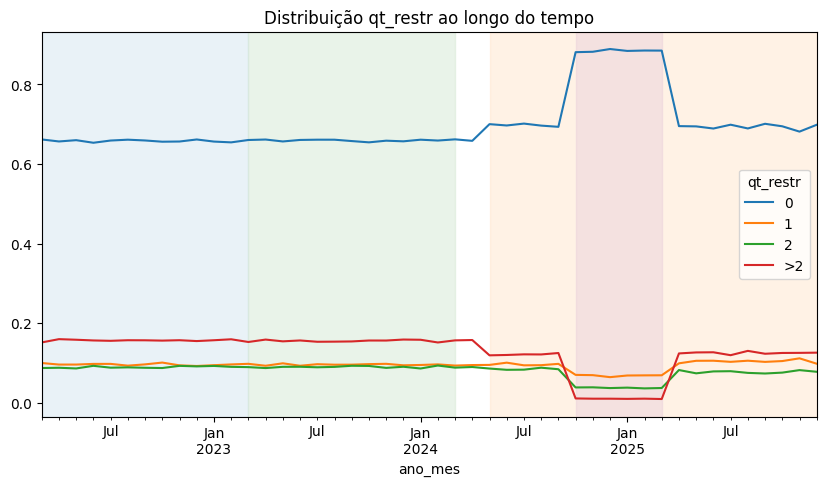

In [37]:
#tabela = pd.crosstab(df['ano_mes'], df['qt_restr'], normalize='index')
tabela = pd.crosstab(df_contratados['ano_mes'], df_contratados['qt_restr'], normalize='index')

ax = tabela.plot(figsize=(10,5))

# Pintar fundo dos diferentes períodos 
ax.axvspan('2022-03-01', '2023-03-01', color='#D4E6F1', alpha=0.5)       # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='#D5E8D4', alpha=0.5)       # janela de observação
#ax.axvspan('2024-03-01', '2024-05-01', color='#E1E1E1', alpha=0.5)       # limbo
ax.axvspan('2024-05-01', tabela.index.max(), color='#FFE6CC', alpha=0.5) # produção
ax.axvspan('2024-10-01', '2025-03-01', color='#EAD1DC', alpha=0.5)       # estranho

plt.title('Distribuição qt_restr ao longo do tempo')
plt.show()
